# Reconstruct Higgs Candidates from `jets.csv`

This notebook:
1. Loads `jets.csv`
2. Keeps only truth-level b-jets (`truth_flavor == 'b'`)
3. Assigns each selected jet to `H1/H2/H3` using max percentage with a >50% purity cut
4. Reconstructs one Higgs candidate per `(event, assigned_higgs)` by summing jet 4-vectors
5. Plots the invariant-mass histogram of all reconstructed Higgs candidates

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

In [ ]:
CSV_PATH = 'ak4_jets.csv'
THRESHOLD = 50  # percent
PT_MIN = 0     # GeV
ETA_MAX = 2.5

df = pd.read_csv(CSV_PATH)
required = ['event', 'px', 'py', 'pz', 'E', 'pt', 'eta', 'H1_percentage', 'H2_percentage', 'H3_percentage', 'truth_flavor']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

len(df), df.head(3)

(177477,
    event  hepmc_event  jet          pt       eta         y       phi  \
 0      0            0    1  373.374573 -1.244345 -1.240445 -3.137681   
 1      0            0    2  220.930156  0.739786  0.726519  0.047063   
 2      0            0    3  104.091063 -0.900220 -0.896723  0.469602   
 
         mass          px         py          pz           E  H1_percentage  \
 0  35.930534 -373.371716  -1.460481 -594.138091  702.637635       2.857143   
 1  46.009857  220.685526  10.393852  178.762508  287.894208       0.000000   
 2  10.316478   92.823025  47.104515 -106.884101  149.551296       4.166667   
 
    H2_percentage  H3_percentage truth_flavor  btag_loose  btag_medium  \
 0      91.428571            0.0            b           1            1   
 1       2.040816            0.0            c           0            0   
 2       0.000000           87.5            b           1            1   
 
    btag_tight  
 0           1  
 1           0  
 2           1  )

In [38]:
hcols = ['H1_percentage', 'H2_percentage', 'H3_percentage']

# Keep only b jets for the analysis
bjets = df[df['truth_flavor'] == 'b'].copy()

# Apply kinematic cuts
bjets = bjets[(bjets['pt'] > PT_MIN) & (bjets['eta'].abs() < ETA_MAX)].copy()

# Jet -> origin Higgs by max percentage
bjets['max_higgs_percentage'] = bjets[hcols].max(axis=1)
bjets['assigned_higgs'] = bjets[hcols].idxmax(axis=1).str.replace('_percentage', '', regex=False)

# Keep only jets with sufficiently pure assignment
sel = bjets[bjets['max_higgs_percentage'] > THRESHOLD].copy()

print(f'Total jets: {len(df)}')
print(f'B jets after cuts (pt > {PT_MIN} GeV, |eta| < {ETA_MAX}): {len(bjets)}')
print(f'Jets passing >{THRESHOLD:.1f}% assignment: {len(sel)}')
sel[['event', 'jet', 'truth_flavor', 'assigned_higgs', 'max_higgs_percentage']].head(10)

Total jets: 177477
B jets after cuts (pt > 0 GeV, |eta| < 2.5): 30203
Jets passing >80.0% assignment: 7588


,event,jet,truth_flavor,assigned_higgs,max_higgs_percentage
0,0,1,b,H2,91.428571
2,0,3,b,H3,87.500000
3,0,4,b,H1,85.000000
135,0,136,b,H3,100.000000
217,1,2,b,H3,100.000000
218,1,3,b,H3,100.000000
220,1,5,b,H2,86.666667
224,1,9,b,H1,90.909091
225,1,10,b,H2,100.000000
227,1,12,b,H1,100.000000


In [39]:
# Reconstruct one Higgs candidate per (event, assigned_higgs)
grp = sel.groupby(['event', 'assigned_higgs'], as_index=False)[['px', 'py', 'pz', 'E']].sum()

p2 = grp['px']**2 + grp['py']**2 + grp['pz']**2
m2 = grp['E']**2 - p2
grp['m_reco'] = np.sqrt(np.clip(m2, 0, None))

print(f'Reconstructed Higgs candidates: {len(grp)}')
grp.head(10)

Reconstructed Higgs candidates: 2604


,event,assigned_higgs,px,py,pz,E,m_reco
0,0,H1,15.942664,-67.802058,-17.823154,72.353506,8.128798
1,0,H2,-373.371716,-1.460481,-594.138091,702.637635,35.930534
2,0,H3,92.203770,46.827620,-107.977812,150.929726,20.644931
3,1,H1,1.444910,22.050880,21.286531,64.496247,56.730243
4,1,H2,-6.692050,-41.848620,-13.570154,56.833721,35.352966
5,1,H3,-168.557411,239.315460,160.349615,356.208649,124.455261
6,2,H1,-1.735515,-56.710557,-90.155767,107.091319,11.017666
7,2,H2,-65.752615,-9.642681,-308.258695,315.695443,14.960008
8,2,H3,-35.590337,25.198316,-9.935027,46.638266,13.221038
9,3,H1,0.439450,-0.244389,1.432996,1.548292,0.301478


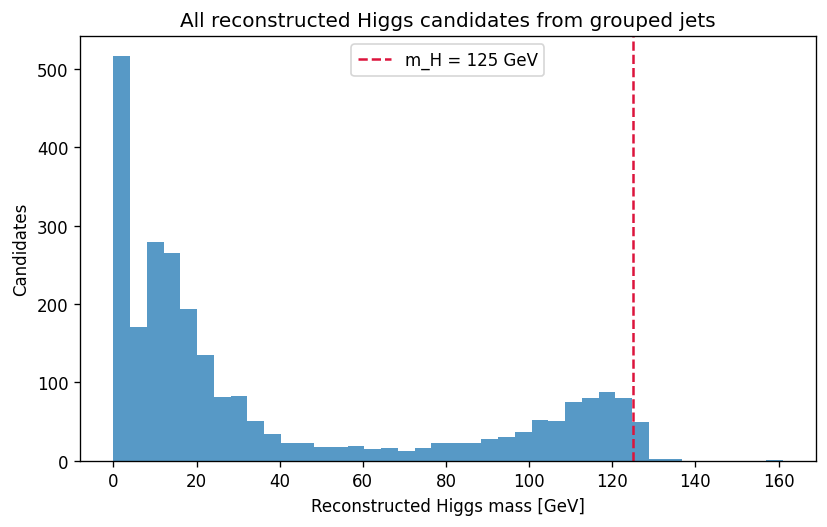

In [40]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(grp['m_reco'], bins=40, histtype='stepfilled', alpha=0.75)
ax.axvline(125.0, color='crimson', linestyle='--', linewidth=1.5, label='m_H = 125 GeV')
ax.set_xlabel('Reconstructed Higgs mass [GeV]')
ax.set_ylabel('Candidates')
ax.set_title('All reconstructed Higgs candidates from grouped jets')
ax.legend()
plt.tight_layout()
plt.show()